# 02 · Baselines & the Evaluation Pipeline

**Amazon Reviews 2023 — Electronics** · Real-time recommendation system

Before building any fancy model, we need two things:

1. **Baselines** — simple, non-personalized recommenders. *"If your model doesn't beat popularity, something is wrong."* They are the bar every later model must clear.
2. **An evaluation pipeline** — the shared 'ruler' (Recall@20, NDCG@10, Catalog Coverage) that scores *every* model identically, so comparisons are fair.

We build both here. The metrics live in `src/recsys/metrics.py` and the baselines in `src/recsys/baselines.py`, so later notebooks (MF-BPR, two-tower, ranking) reuse the exact same code — no drift.

> **Why these three metrics?** *Retrieval optimizes Recall* (find all the good items), *ranking optimizes NDCG* (put them in the right order), and *Catalog Coverage* guards against a model that only ever recommends the same few blockbusters.

## 0 · Setup

In [1]:
import sys, os
from pathlib import Path

try:
    import google.colab  # noqa
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/rec-system')  # <-- adjust to your Drive path
except ImportError:
    PROJECT = Path('..').resolve()

DATA_DIR = PROJECT / 'data'
sys.path.insert(0, str(PROJECT / 'src'))
print('Data:', DATA_DIR, '(exists:', DATA_DIR.exists(), ')')

Data: F:\Rec_System\data (exists: True )


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)

## 1 · Load the time-based splits

We reuse the leakage-free splits produced in notebook `01`. Train = past, test = future.

In [3]:
SPLIT = DATA_DIR / 'splits'
train = pd.read_parquet(SPLIT / 'train.parquet')
test  = pd.read_parquet(SPLIT / 'test.parquet')
items = pd.read_parquet(DATA_DIR / 'items.parquet')
n_items = int(pd.read_parquet(DATA_DIR / 'item_map.parquet').shape[0])

# per-user ground truth = positive test items, restricted to users/items seen in train
gt_df = pd.read_parquet(SPLIT / 'test_ground_truth.parquet')
ground_truth = {int(u): set(v) for u, v in zip(gt_df.index, gt_df['items'])}

print(f'train interactions : {len(train):,}')
print(f'catalog size       : {n_items:,}')
print(f'evaluable users    : {len(ground_truth):,}')
print(f'avg positives/user : {np.mean([len(v) for v in ground_truth.values()]):.2f}')

train interactions : 231,332
catalog size       : 20,450
evaluable users    : 6,962
avg positives/user : 2.32


## 2 · The evaluation metrics (in plain terms)

Our shared scorer is `evaluate_recommendations`. For each user we produce a ranked list of item recommendations (best first), then compare it against that user's **ground-truth** items — the products they actually liked in the test period.

**What is `K`?** `K` is the number of top recommendations we evaluate — the length of the recommendation list we look at. `Recall@20` judges the top **20** recommendations; `NDCG@10` judges the top **10**.

Every metric compares two sets: **relevant** (the items the user actually liked) and **recommended** (the top-K items we showed). Their overlap **∩** is the set of **hits** — the items we got right.

| Metric | In one sentence | Formula ( `#X` = count of X ) |
|---|---|---|
| **Recall@K** | Of the items the user liked, what fraction did we find in the top-K? | `#(recommended ∩ relevant) / #relevant` |
| **Precision@K** | Of the K items we showed, what fraction were correct? | `#(recommended ∩ relevant) / K` |
| **NDCG@K** | Did we put the correct items *high* in the list, not just present? | `DCG@K / IDCG@K` |
| **Coverage** | Across all users, what % of the whole catalog did we ever recommend? | `#distinct recs / #items` |

**Recall** measures whether we *find* the good items (the priority for retrieval); **NDCG** measures whether we *order* them well (the priority for ranking); **Coverage** is a diversity guardrail — a model that only ever recommends the same few popular items scores high on accuracy but low here.

In [4]:
from recsys.metrics import evaluate_recommendations

# quick sanity check on a tiny hand-built example
demo_recs = {0: [10, 11, 12, 13, 14]}   # ranked recommendations
demo_gt   = {0: {10, 12}}               # user actually liked items 10 and 12
print(evaluate_recommendations(demo_recs, demo_gt, n_items=100, ks=(5,), coverage_k=5))
# Recall@5 = 2/2 = 1.0 (found both); hits at ranks 1 and 3 -> NDCG < 1

{'Recall@5': 1.0, 'Precision@5': 0.4, 'NDCG@5': 0.9197207891481876, 'Coverage@5': 0.05}


> **Interpretation.** Both liked items are retrieved (Recall@5 = 1.0), but because the second hit sits at position 3 instead of 2, NDCG@5 is below 1.0 — exactly the rank-awareness we want.

## 3 · Baseline 1 — Random recommender

The absolute floor: recommend K random items the user hasn't already seen. With ~20k items and a handful of correct answers per user, this should score **almost zero** on accuracy — but **~100% coverage** (it spreads across the whole catalog). Anything we build later must crush this.

In [5]:
from recsys.baselines import build_seen, recommend_random
from recsys.baselines import popularity_ranking, recency_ranking, recommend_from_global_ranking

K = 20                       # we report @20 (Recall/Coverage) and @10 (NDCG)
eval_users = list(ground_truth.keys())
seen = build_seen(train)     # items each user already interacted with in train

random_recs = recommend_random(eval_users, n_items, seen, k=50, seed=42)
random_metrics = evaluate_recommendations(random_recs, ground_truth, n_items)
random_metrics

{'Recall@10': 0.0005314564780235564,
 'Precision@10': 7.181844297615628e-05,
 'NDCG@10': 0.0003663751390237356,
 'Recall@20': 0.001186271693394393,
 'Precision@20': 9.336397586900318e-05,
 'NDCG@20': 0.0005463406507545474,
 'Recall@50': 0.0020447622987093744,
 'Precision@50': 8.618213157138754e-05,
 'NDCG@50': 0.0007584089984044173,
 'Coverage@20': 0.998679706601467}

## 4 · Baseline 2 — Popularity recommender

Recommend the **most-reviewed items in the training set** to everyone (minus what each user already saw). No personalization — everyone gets almost the same list — but popular items are popular *for a reason*, so this is a genuinely strong, cold-start-safe bar.

We rank items by their number of **positive** training interactions.

In [6]:
pop_rank = popularity_ranking(train, positive_only=True)   # item_idx sorted by train popularity
pop_recs = recommend_from_global_ranking(eval_users, pop_rank, seen, k=50)
pop_metrics = evaluate_recommendations(pop_recs, ground_truth, n_items)
pop_metrics

{'Recall@10': 0.006445363264524426,
 'Precision@10': 0.0015081873024992817,
 'NDCG@10': 0.003411683661056963,
 'Recall@20': 0.01148642562590124,
 'Precision@20': 0.0013286411950588911,
 'NDCG@20': 0.004977692809348841,
 'Recall@50': 0.02501860934439887,
 'Precision@50': 0.001120367710428038,
 'NDCG@50': 0.008214350335462877,
 'Coverage@20': 0.00117359413202934}

### The 10 most popular items (what a logged-out homepage would show)

In [7]:
top10 = pop_rank[:10]
items.set_index('item_idx').loc[top10, ['title', 'category', 'average_rating']]

,title,category,average_rating
item_idx,,,
712,"Echo Dot (3rd Gen, 2018 release) - Smart speak...",Amazon Devices,4.7
2337,"Echo Show 5 (2nd Gen, 2021 release) | Smart di...",Amazon Devices,4.6
18699,"Fire TV Stick 4K, brilliant 4K streaming quali...",Amazon Devices,4.7
1739,Echo Dot (4th Gen) | Smart speaker with Alexa ...,Amazon Devices,4.7
2281,Fire TV Stick (3rd Gen) with Alexa Voice Remot...,Amazon Devices,4.7
12917,"Blink Video Doorbell | Two-way audio, HD video...",Amazon Devices,4.3
2907,Fire TV Gaming Bundle with Fire TV Stick 4K Ma...,Amazon Devices,4.7
4034,SAMSUNG EVO Select Micro SD-Memory-Card + Adap...,Micro SD Cards,4.7
16704,Blink Mini – Compact indoor plug-in smart secu...,Amazon Devices,4.4


## 5 · Baseline 3 — Recency (optional)

Recommend the items with the **most recent** training interactions. Good for trending/news domains; a useful extra comparison point for Electronics.

In [8]:
rec_rank = recency_ranking(train, positive_only=True)
recency_recs = recommend_from_global_ranking(eval_users, rec_rank, seen, k=50)
recency_metrics = evaluate_recommendations(recency_recs, ground_truth, n_items)
recency_metrics

{'Recall@10': 0.0030322684029549605,
 'Precision@10': 0.0007612754955472565,
 'NDCG@10': 0.001645520237004994,
 'Recall@20': 0.005210574359100013,
 'Precision@20': 0.0005960930767020972,
 'NDCG@20': 0.002237624220868548,
 'Recall@50': 0.013774965663425797,
 'Precision@50': 0.000571674806090204,
 'NDCG@50': 0.0041916847431713875,
 'Coverage@20': 0.0010757946210268948}

## 6 · Results — the bar every model must beat

In [9]:
results = pd.DataFrame({
    'Random':     random_metrics,
    'Popularity': pop_metrics,
    'Recency':    recency_metrics,
}).T
report_cols = ['Recall@20', 'Recall@50', 'NDCG@10', 'Coverage@20']
results[report_cols].style.format('{:.4f}')

,Recall@20,Recall@50,NDCG@10,Coverage@20
Random,0.0012,0.0020,0.0004,0.9987
Popularity,0.0115,0.0250,0.0034,0.0012
Recency,0.0052,0.0138,0.0016,0.0011


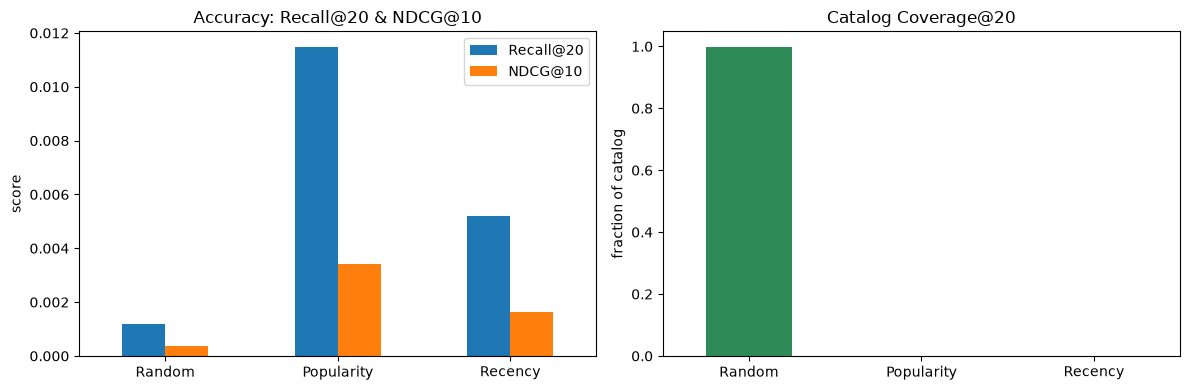

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
results[['Recall@20', 'NDCG@10']].plot(kind='bar', ax=ax[0])
ax[0].set(title='Accuracy: Recall@20 & NDCG@10', ylabel='score'); ax[0].tick_params(axis='x', rotation=0)
results[['Coverage@20']].plot(kind='bar', ax=ax[1], color='seagreen', legend=False)
ax[1].set(title='Catalog Coverage@20', ylabel='fraction of catalog'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

> **Interpretation — the accuracy vs coverage trade-off.**

- **Random** gets near-zero Recall/NDCG but ~100% coverage: it recommends everywhere and hits nothing. Useless, but the correct *floor*.
- **Popularity** is dramatically better on accuracy despite zero personalization — the classic 'surprisingly hard to beat' baseline. But its coverage is tiny: every user sees the same ~20 head items, so the long tail is never surfaced.
- **Recency** sits in between and shows how a different ranking of the same items shifts both axes.

This is the central tension of recommendation: accuracy pulls toward popular items, coverage pulls toward the long tail. **MF-BPR and the two-tower model must beat Popularity's accuracy *while* improving coverage** — that's how we'll know personalization is actually working.

## 7 · Save baseline results

Later notebooks append their own rows to this table for the final side-by-side comparison.

In [11]:
RESULTS_DIR = DATA_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
results.to_parquet(RESULTS_DIR / 'baselines.parquet')
print('saved ->', RESULTS_DIR / 'baselines.parquet')
results[report_cols].round(4)

saved -> F:\Rec_System\data\results\baselines.parquet


,Recall@20,Recall@50,NDCG@10,Coverage@20
Random,0.0012,0.0020,0.0004,0.9987
Popularity,0.0115,0.0250,0.0034,0.0012
Recency,0.0052,0.0138,0.0016,0.0011


---


**Produced:** a reusable evaluation pipeline (`metrics.py`) and three non-personalized baselines (`baselines.py`), with Recall@20 / NDCG@10 / Catalog Coverage reported and interpreted. Popularity is the bar to beat.

